# F&S Demo
Example of how we would use echo to do some optimisation of a building on campus

## Import required modules

In [138]:
import numpy as np
import pandas as pd

from echo.echo_models import *
from echo.echo_optimiser import *
from echo.objectives import *
from echo.bz_utils import *

## Define some model parameters

In [139]:
time_periods = 8760  # number of intervals
interval_duration = 60  # in minutes
expansion_periods = 1  # no planning periods

## Create some electrical load profile and solar generation profile

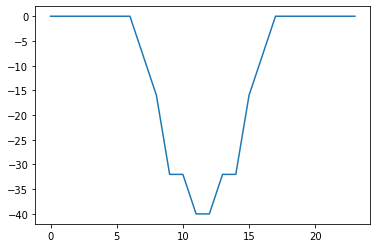

In [140]:
load_profile = [100] * time_periods
solar_system_size = 40  # system size in kW
solar_daily_profile = [0]*7 + [0.2]*1 +[0.4]*1 + [0.8]*2 + [1]*2 + [0.8]*2 + [0.4]*1 + [0.2]*1 + [0]*7
solar_profile = np.array(solar_daily_profile * 365) * solar_system_size * -1
plt.plot(solar_profile[0:24])

## Generate a gas consumption profile using standard seasonal profiles (provided by Guy)


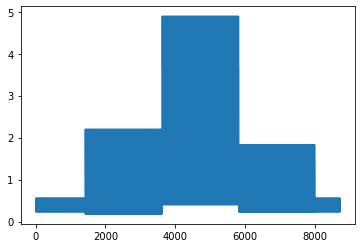

5466.182526881601


In [141]:
seasonal_gas_averages = {'Autumn': 409/31/24,
                         'Winter': 910/31/24,
                         'Spring': 340/31/24,
                         'Summer': 196/31/24}  # 2019 hourly seasonal averages for SoM

df = pd.read_csv('../../bz_data/gas_profile_soad_som.csv')
gas_load = gas_profiler(seasonal_profile_df=df,
                        season_multiplier=seasonal_gas_averages,
                        start_date="2019-01-01",
                        end_date="2019-12-31")

# Plot the data to see if it looks right - values are in GJ ?
plt.plot(gas_load['profile'].values)
plt.show()

# Print the total consumption for the year
print(sum(gas_load['profile'].values))

# Define some energy and gas tariffs
## For simplicity in this example, let's just use one electricity and one gas tariff that apply at all times

In [142]:
# Retail energy tariffs ($/kWh)
elec_rate = 0.09

# Gas tariff
gas_rate = 17  # in $/GJ

## Define a CO2 factor associated with importing gas from the network

In [143]:
emission_factor = 60  # 60 kg Co2e/GJ gas

# Build echo nodes and edges
## First we build all the ports and nodes, since these represent our assets

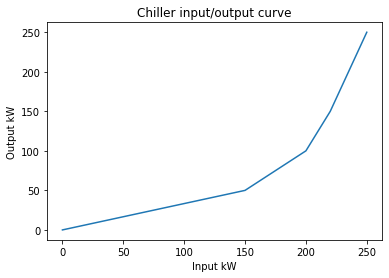

In [144]:
bulk_grid_node = Node()  # build a node
bulk_grid_node.add_electrical_port('grid') # add an electrical port to connect to

connection_pt_node = TellegenNode()  # create a 'summing' node to connect all our assets to
connection_pt_node.add_electrical_ports_from_list(['upstream', 'load', 'battery', 'chiller', 'solar'])  # create a port on this node for each asset we will connect

# Load node
load_node = Node()
load_port = ElectricalDemand()
load_port.add_demand_profile_from_array(load_profile)  # add our load data in kW to this port - it will become a fixed parameter
load_node.ports['load'] = load_port  # add the port to the node

# Chiller node
chiller_node = Chiller(max_output=-250,
                       max_input=250) # Rating in kW

# Define points on our piecewise function that maps chiller input to output.
input_breakpoints = [0, 150, 200, 220, 250]
output_values = [0, -50, -100, -150, -250]

# Plot
plt.plot(input_breakpoints, np.array(output_values)*-1)
plt.xlabel('Input kW')
plt.ylabel('Output kW')
plt.title('Chiller input/output curve')
plt.show()

chiller_node.set_input_output_breakpoints(input_array=input_breakpoints,
                                          output_array=output_values,
                                          time_periods=time_periods,
                                          expansion_periods=expansion_periods)


# Solar node
solar_node = Node()
solar_port = ElectricalGeneration()
solar_port.add_generation_profile_from_array(solar_profile)
solar_node.ports['solar'] = solar_port

# Battery
battery_node = Node()
battery_size = 100 # kWh storage capacity
charge_limit = 10  # kW
battery_port = ElectricalStorage(max_capacity=battery_size,
                       depth_of_discharge_limit=0,
                       charging_power_limit=charge_limit,
                       discharging_power_limit=-charge_limit,
                       charging_efficiency=1,
                       discharging_efficiency=1,
                       initial_state_of_charge=0.0)
battery_node.ports['battery'] = battery_port


### GAS

# Bulk network node, with a port for emissions

bulk_gas_node = Node()
bulk_gas_node.add_flex_port('gas_supply', unit=Units.JPS)
bulk_gas_node.add_flex_port('emissions', unit=Units.CO2)
bulk_gas_node.add_emission_transformation(emitting_port=bulk_gas_node.ports['gas_supply'],
                                          carbon_port=bulk_gas_node.ports['emissions'],
                                          emission_factor=emission_factor)

# Gas CP node
gas_connection_pt_node = TellegenNode()
gas_connection_pt_node.add_flex_ports_from_list(['upstream', 'load'], unit=Units.JPS)

gas_load_node = Node()
gas_load_port = GasDemand()
gas_load_port.add_sink_profile_from_array(gas_load['profile'].values)
gas_load_node.ports['load'] = gas_load_port

# Node for aggregating carbon emissions
carbon_agg_node = CarbonAggregation()
carbon_agg_node.add_flex_port('gas_emissions', unit=Units.CO2)
carbon_agg_node.add_aggregation_transformation()

# Create an optimisation graph and add all our nodes to the graph
system = OptimisationGraph()
system.add_node_obj([bulk_grid_node, connection_pt_node, solar_node, chiller_node, battery_node, load_node, gas_load_node, bulk_gas_node, carbon_agg_node, gas_connection_pt_node])

## Next we build all the edges which represent connectivity

In [145]:
# Electrical
system.connect_ports_and_create_edge(bulk_grid_node.ports['grid'], connection_pt_node.ports['upstream'])
system.connect_ports_and_create_edge(connection_pt_node.ports['load'], load_node.ports['load'])
system.connect_ports_and_create_edge(connection_pt_node.ports['battery'], battery_node.ports['battery'])
system.connect_ports_and_create_edge(connection_pt_node.ports['solar'], solar_node.ports['solar'])
system.connect_ports_and_create_edge(connection_pt_node.ports['chiller'], chiller_node.ports['input'])

# Gas
system.connect_ports_and_create_edge(bulk_gas_node.ports['gas_supply'], gas_connection_pt_node.ports['upstream'])
system.connect_ports_and_create_edge(gas_connection_pt_node.ports['load'], gas_load_node.ports['load'])

# CO2
system.connect_ports_and_create_edge(bulk_gas_node.ports['emissions'], carbon_agg_node.ports['gas_emissions'])


## Now we have a model of the network, which contains some fixed data as well as some optimisable variables.
## We can now define some objectives with reference to components in this network
### Eg import tariffs on the electrical energy imported from the bulk grid

In [146]:
elec_tariff = ImportTariff(component=connection_pt_node.ports['upstream'],
                           tariff_array=[elec_rate]*time_periods)

gas_tariff = ImportTariff(component=gas_connection_pt_node.ports['upstream'],
                          tariff_array=[gas_rate]*time_periods)


# Define a set of objectives
objective_set = ObjectiveSet(objective_list=[elec_tariff, gas_tariff])

## Now we can call the optimiser

In [147]:
optimiser = EchoOptimiser(
    interval_duration=interval_duration,
    number_of_intervals=time_periods,
    number_of_expansion_intervals=expansion_periods,
    discount_rate=0,
    ES=system, # this is our model
    objective_set=objective_set,  # these are our objectives
    profile=None
)

optimiser.optimise(tee=True)  # optimise the example

TypeError: unsupported operand type(s) for *: 'int' and 'NoneType'

### Check optimiser status and look at some results

In [ ]:
print(optimiser.opt_status)

## Plot the optimised connection point
opt_cp = optimiser.values(connection_pt_node.ports['upstream'])
plt.plot(opt_cp)

In [ ]:
# Calculate the total emissions over the year
total_emissions = sum(optimiser.values(carbon_agg_node.ports['sum']))
print('total emissions: ', total_emissions)